# 06_2. Python Swap, FX Forward, and Cap/Floor Pricing

This companion notebook takes the same "explicit trade object plus direct Python pricer" style used in the
Bermudan example and applies it to three simpler products. The goal is not engine comparison. It is to show
how to build inspectable pricing examples for a vanilla swap, an FX forward, and a cap/floor directly from
Python definitions.

**Purpose**
- price one vanilla swap directly from ORE-style leg arrays
- price one EUR/USD FX forward directly from the hybrid IR/FX model
- price one cap and one floor from explicit coupon schedules

**What you will learn**
- how to reuse ORE-style leg arrays for direct Python swap pricing
- how the FX forward pricer fits into the two-currency hybrid setup
- how to keep the notebook focused on standalone prices rather than XVA workflows


In [1]:
from pathlib import Path
import os
import sys

def _pythonorerunner_root(candidate: Path) -> bool:
    return (
        (candidate / "notebook_series" / "series_helpers.py").exists()
        and ((candidate / "pythonore").exists() or (candidate / "src" / "pythonore").exists())
    )

def _engine_root(candidate: Path) -> bool:
    return (candidate / "Tools" / "PythonOreRunner" / "notebook_series" / "series_helpers.py").exists()

def _find_repo_root(start: Path) -> Path:
    current = start.resolve()
    for candidate in (current, *current.parents):
        if _pythonorerunner_root(candidate) or _engine_root(candidate):
            return candidate
    repo_hint = Path("/Users/gordonlee/Documents/Engine")
    if _engine_root(repo_hint):
        return repo_hint
    standalone_hint = Path("/Users/gordonlee/Documents/PythonOreRunner")
    if _pythonorerunner_root(standalone_hint):
        return standalone_hint
    raise RuntimeError("Could not locate the notebook repo root from the current notebook working directory")

REPO_ROOT = _find_repo_root(Path.cwd())
NOTEBOOK_DIR = REPO_ROOT / "notebook_series" if _pythonorerunner_root(REPO_ROOT) else REPO_ROOT / "Tools" / "PythonOreRunner" / "notebook_series"
for path in (NOTEBOOK_DIR, REPO_ROOT):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

os.environ.setdefault("MPLCONFIGDIR", "/tmp/codex-mplconfig")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import series_helpers as nh

try:
    from IPython.display import display
except Exception:
    def display(obj):
        if hasattr(obj, "to_string"):
            print(obj.to_string())
        else:
            print(obj)

repo = nh.bootstrap_notebook_env(REPO_ROOT)
nh.apply_plot_style()
print(repo)


/Users/gordonlee/Documents/PythonOreRunner


In [2]:
from py_ore_tools.lgm import LGM1F, LGMParams, simulate_lgm_measure
from py_ore_tools.lgm_fx_xva_utils import FxForwardDef, build_two_ccy_hybrid, fx_forward_npv
from py_ore_tools.lgm_ir_options import CapFloorDef, capfloor_npv_paths
from py_ore_tools.irs_xva_utils import build_discount_curve_from_zero_rate_pairs, swap_npv_from_ore_legs_dual_curve

params = LGMParams(
    alpha_times=(1.0, 2.0, 4.0),
    alpha_values=(0.010, 0.012, 0.015, 0.013),
    kappa_times=(2.0,),
    kappa_values=(0.035, 0.028),
    shift=0.0,
    scaling=1.0,
)
model = LGM1F(params)
p0_disc = build_discount_curve_from_zero_rate_pairs([(0.0, 0.028), (10.0, 0.031)])
p0_fwd = build_discount_curve_from_zero_rate_pairs([(0.0, 0.029), (10.0, 0.032)])
ir_times = np.linspace(0.0, 5.0, 21)
ir_x_paths = simulate_lgm_measure(model, ir_times, n_paths=4096, rng=np.random.default_rng(42))

def summarize_price(name: str, npv_paths: np.ndarray) -> dict[str, float]:
    values = np.asarray(npv_paths, dtype=float)
    return {
        "trade": name,
        "t0_npv": float(np.mean(values[0, :])),
        "t0_std": float(np.std(values[0, :])),
        "t0_p05": float(np.quantile(values[0, :], 0.05)),
        "t0_p95": float(np.quantile(values[0, :], 0.95)),
    }

def mark_to_market_frame(name: str, times: np.ndarray, npv_paths: np.ndarray) -> pd.DataFrame:
    values = np.asarray(npv_paths, dtype=float)
    return pd.DataFrame(
        {
            "trade": name,
            "time": np.asarray(times, dtype=float),
            "mean_npv": np.mean(values, axis=1),
            "p05_npv": np.quantile(values, 0.05, axis=1),
            "p95_npv": np.quantile(values, 0.95, axis=1),
        }
    )


## Swap pricing

The swap uses the same array-style leg definition as the Bermudan notebook, but here we price the underlying
directly. That is the cleanest way to show what the pathwise swap pricer is doing before any optionality is added.


In [3]:
fixed_start = np.array([1.0, 2.0, 3.0, 4.0], dtype=float)
fixed_end = np.array([2.0, 3.0, 4.0, 5.0], dtype=float)
float_start = np.array([1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5], dtype=float)
float_end = float_start + 0.5
swap_legs = {
    "fixed_start_time": fixed_start,
    "fixed_end_time": fixed_end,
    "fixed_pay_time": fixed_end.copy(),
    "fixed_accrual": np.ones_like(fixed_end),
    "fixed_rate": np.full_like(fixed_end, 0.032),
    "fixed_notional": np.full_like(fixed_end, 10_000_000.0),
    "fixed_sign": np.full_like(fixed_end, -1.0),
    "fixed_amount": np.full_like(fixed_end, -320_000.0),
    "float_pay_time": float_end,
    "float_start_time": float_start,
    "float_end_time": float_end,
    "float_accrual": np.full_like(float_start, 0.5),
    "float_notional": np.full_like(float_start, 10_000_000.0),
    "float_sign": np.full_like(float_start, 1.0),
    "float_spread": np.zeros_like(float_start),
    "float_coupon": np.zeros_like(float_start),
}
swap_npv_paths = np.vstack(
    [
        swap_npv_from_ore_legs_dual_curve(model, p0_disc, p0_fwd, swap_legs, float(t), ir_x_paths[i, :])
        for i, t in enumerate(ir_times)
    ]
)
swap_summary = pd.DataFrame([summarize_price("payer_swap", swap_npv_paths)])

swap_schedule = pd.DataFrame(
    {
        "fixed_start_time": pd.Series(swap_legs["fixed_start_time"]),
        "fixed_end_time": pd.Series(swap_legs["fixed_end_time"]),
        "fixed_rate": pd.Series(swap_legs["fixed_rate"]),
        "float_start_time": pd.Series(swap_legs["float_start_time"]),
        "float_end_time": pd.Series(swap_legs["float_end_time"]),
    }
)
display(swap_summary)
display(swap_schedule)
display(nh.lgm_params_frame(params))


,trade,t0_npv,t0_std,t0_p05,t0_p95
0,payer_swap,-27164.294528,0.0,-27164.294528,-27164.294528


,fixed_start_time,fixed_end_time,fixed_rate,float_start_time,float_end_time
0,1.0,2.0,0.032,1.0,1.5
1,2.0,3.0,0.032,1.5,2.0
2,3.0,4.0,0.032,2.0,2.5
3,4.0,5.0,0.032,2.5,3.0
4,NaN,NaN,NaN,3.0,3.5
5,NaN,NaN,NaN,3.5,4.0
6,NaN,NaN,NaN,4.0,4.5
7,NaN,NaN,NaN,4.5,5.0


,alpha_time,alpha_value,kappa_time,kappa_value
0,1.0,0.010,2.0,0.035
1,2.0,0.012,terminal,0.028
2,4.0,0.015,NaN,NaN
3,terminal,0.013,NaN,NaN


,trade,time,mean_npv,p05_npv,p95_npv
0,payer_swap,0.00,-27164.294528,-27164.294528,-27164.294528
1,payer_swap,0.25,-30443.121438,-319039.178683,243908.410521
2,payer_swap,0.50,-29192.361050,-432939.469929,358419.349468
3,payer_swap,0.75,-32821.260532,-511105.913072,441447.380129
4,payer_swap,1.00,-177608.746530,-672795.158512,308321.645557


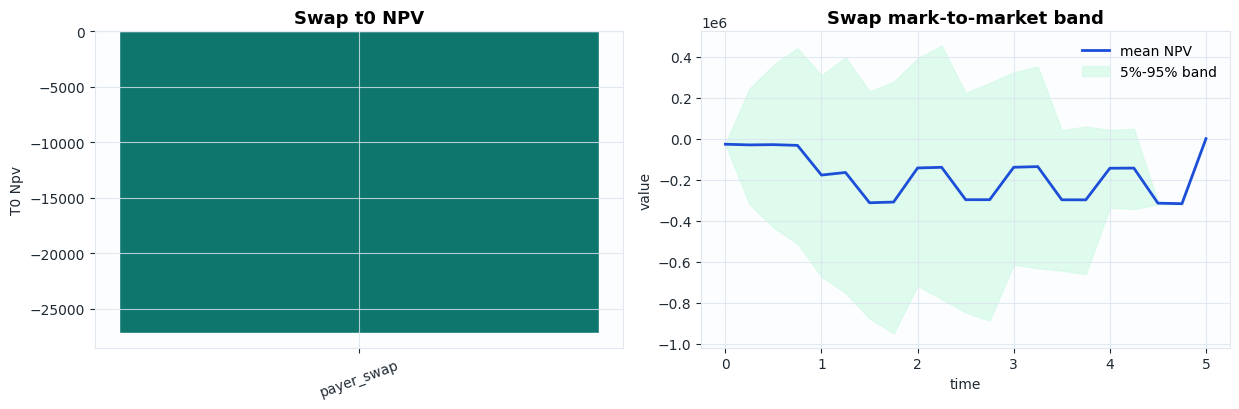

In [4]:
swap_mtm = mark_to_market_frame("payer_swap", ir_times, swap_npv_paths)
display(swap_mtm.head())

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.2))
nh.plot_bar_frame(swap_summary, "trade", "t0_npv", title="Swap t0 NPV", color=nh.PALETTE["teal"], ax=axes[0])
axes[1].plot(swap_mtm["time"], swap_mtm["mean_npv"], label="mean NPV", color=nh.PALETTE["blue"], linewidth=2.0)
axes[1].fill_between(
    swap_mtm["time"],
    swap_mtm["p05_npv"],
    swap_mtm["p95_npv"],
    color=nh.PALETTE["mint"],
    alpha=0.65,
    label="5%-95% band",
)
axes[1].set_title("Swap mark-to-market band")
axes[1].set_xlabel("time")
axes[1].set_ylabel("value")
axes[1].legend()
plt.tight_layout()
plt.show()
plt.close(fig)


The swap chart is a pricing diagnostic, not an exposure report. It shows how the direct swap pricer evolves the
mark-to-market across the simulation grid and how wide the simulated valuation band becomes through time.


## Cap and floor pricing

The cap and floor reuse one coupon schedule so the notebook isolates option-type effects rather than schedule
differences. Both instruments are priced pathwise from the same one-factor LGM model and dual-curve setup.


In [5]:
coupon_start = np.array([1.0, 1.5, 2.0, 2.5, 3.0, 3.5], dtype=float)
coupon_end = coupon_start + 0.5
common_cf_kwargs = {
    "ccy": "EUR",
    "start_time": coupon_start,
    "end_time": coupon_end,
    "pay_time": coupon_end.copy(),
    "accrual": np.full_like(coupon_start, 0.5),
    "notional": np.full_like(coupon_start, 5_000_000.0),
    "fixing_time": coupon_start.copy(),
    "position": 1.0,
}
cap_def = CapFloorDef(
    trade_id="CAP_PY_ONLY",
    option_type="cap",
    strike=np.full_like(coupon_start, 0.031),
    **common_cf_kwargs,
)
floor_def = CapFloorDef(
    trade_id="FLOOR_PY_ONLY",
    option_type="floor",
    strike=np.full_like(coupon_start, 0.027),
    **common_cf_kwargs,
)
cap_npv_paths = capfloor_npv_paths(model, p0_disc, p0_fwd, cap_def, ir_times, ir_x_paths, lock_fixings=True)
floor_npv_paths = capfloor_npv_paths(model, p0_disc, p0_fwd, floor_def, ir_times, ir_x_paths, lock_fixings=True)

capfloor_summary = pd.DataFrame(
    [
        summarize_price("cap", cap_npv_paths),
        summarize_price("floor", floor_npv_paths),
    ]
)
capfloor_schedule = pd.DataFrame(
    {
        "start_time": coupon_start,
        "end_time": coupon_end,
        "cap_strike": cap_def.strike,
        "floor_strike": floor_def.strike,
        "notional": cap_def.notional,
    }
)
display(capfloor_summary)
display(capfloor_schedule)


,trade,t0_npv,t0_std,t0_p05,t0_p95
0,cap,85964.322051,0.000000e+00,85964.322051,85964.322051
1,floor,64400.186255,2.182787e-11,64400.186255,64400.186255


,start_time,end_time,cap_strike,floor_strike,notional
0,1.0,1.5,0.031,0.027,5000000.0
1,1.5,2.0,0.031,0.027,5000000.0
2,2.0,2.5,0.031,0.027,5000000.0
3,2.5,3.0,0.031,0.027,5000000.0
4,3.0,3.5,0.031,0.027,5000000.0
5,3.5,4.0,0.031,0.027,5000000.0


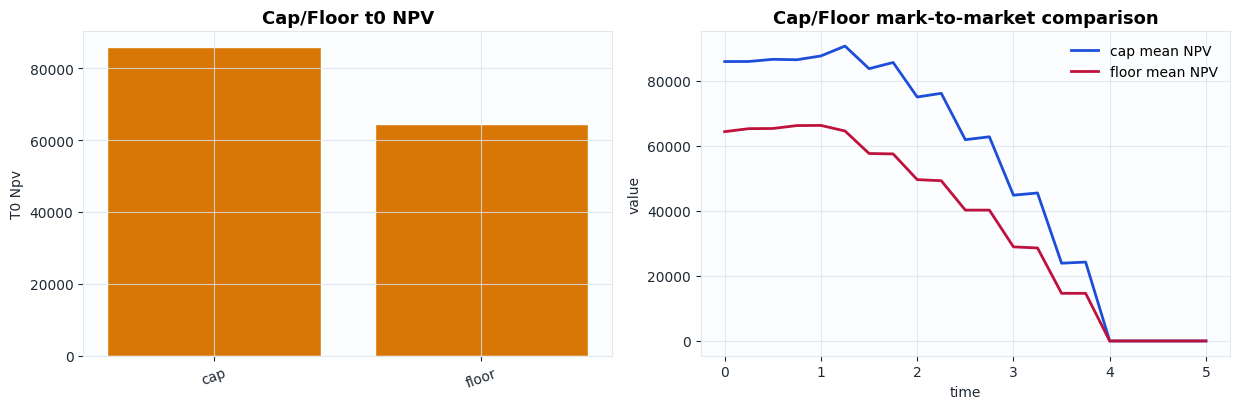

In [6]:
cap_mtm = mark_to_market_frame("cap", ir_times, cap_npv_paths)
floor_mtm = mark_to_market_frame("floor", ir_times, floor_npv_paths)

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.2))
nh.plot_bar_frame(capfloor_summary, "trade", "t0_npv", title="Cap/Floor t0 NPV", color=nh.PALETTE["gold"], ax=axes[0])
axes[1].plot(cap_mtm["time"], cap_mtm["mean_npv"], label="cap mean NPV", color=nh.PALETTE["blue"], linewidth=2.0)
axes[1].plot(floor_mtm["time"], floor_mtm["mean_npv"], label="floor mean NPV", color=nh.PALETTE["rose"], linewidth=2.0)
axes[1].set_title("Cap/Floor mark-to-market comparison")
axes[1].set_xlabel("time")
axes[1].set_ylabel("value")
axes[1].legend()
plt.tight_layout()
plt.show()
plt.close(fig)


The cap/floor comparison stays in pricing space as well. On the same schedule, different strikes and option
direction change both the t0 price and the mean mark-to-market path.


## FX forward pricing

The FX forward uses the hybrid IR/FX model because the product depends on both discounting curves and the FX spot
process. The setup stays explicit: one pair, one strike, one maturity, and one reporting currency.


In [7]:
p0_eur = build_discount_curve_from_zero_rate_pairs([(0.0, 0.020), (5.0, 0.022)])
p0_usd = build_discount_curve_from_zero_rate_pairs([(0.0, 0.030), (5.0, 0.033)])
fx_times = np.linspace(0.0, 2.5, 11)

hybrid = build_two_ccy_hybrid(
    pair="EUR/USD",
    ir_specs={
        "EUR": {"alpha": 0.010, "kappa": 0.030},
        "USD": {"alpha": 0.012, "kappa": 0.025},
    },
    fx_vol=0.14,
    corr_dom_fx=-0.20,
    corr_for_fx=0.15,
)
fx_def = FxForwardDef(
    trade_id="FXFWD_PY_ONLY",
    pair="EUR/USD",
    notional_base=2_000_000.0,
    strike=1.10,
    maturity=2.0,
)
fx_sim = hybrid.simulate_paths(
    fx_times,
    4096,
    rng=np.random.default_rng(7),
    log_s0={"EUR/USD": np.log(1.08)},
)
fx_npv_paths = np.vstack(
    [
        fx_forward_npv(
            hybrid,
            fx_def,
            float(t),
            fx_sim["s"]["EUR/USD"][i, :],
            fx_sim["x"]["USD"][i, :],
            fx_sim["x"]["EUR"][i, :],
            p0_usd,
            p0_eur,
        )
        for i, t in enumerate(fx_times)
    ]
)
fx_summary = pd.DataFrame([summarize_price("eurusd_fx_forward", fx_npv_paths)])
fx_setup = pd.DataFrame(
    [
        {"field": "pair", "value": fx_def.pair},
        {"field": "spot0", "value": 1.08},
        {"field": "strike", "value": fx_def.strike},
        {"field": "maturity", "value": fx_def.maturity},
        {"field": "notional_base", "value": fx_def.notional_base},
        {"field": "domestic_curve_label", "value": "USD"},
        {"field": "foreign_curve_label", "value": "EUR"},
    ]
)
display(fx_summary)
display(fx_setup)


,trade,t0_npv,t0_std,t0_p05,t0_p95
0,eurusd_fx_forward,5071.935844,1.818989e-12,5071.935844,5071.935844


,field,value
0,pair,EUR/USD
1,spot0,1.08
2,strike,1.1
3,maturity,2.0
4,notional_base,2000000.0
5,domestic_curve_label,USD
6,foreign_curve_label,EUR


,trade,time,mean_npv,p05_npv,p95_npv
0,eurusd_fx_forward,0.00,5071.935844,5071.935844,5071.935844
1,eurusd_fx_forward,0.25,-247.676706,-231001.390274,248786.006913
2,eurusd_fx_forward,0.50,-5433.464240,-322347.445433,340866.933865
3,eurusd_fx_forward,0.75,-14493.527416,-397072.749521,401536.210914
4,eurusd_fx_forward,1.00,-15182.630712,-463268.095607,493298.140341


,time,mean_spot
0,0.00,1.080000
1,0.25,1.080076
2,0.50,1.080366
3,0.75,1.078608
4,1.00,1.081081


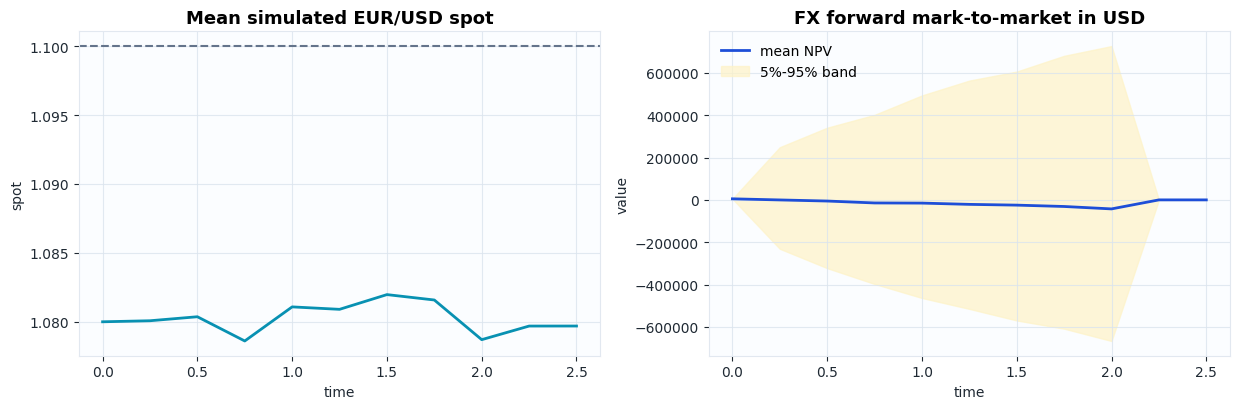

In [8]:
fx_mtm = mark_to_market_frame("eurusd_fx_forward", fx_times, fx_npv_paths)
fx_spot_summary = pd.DataFrame(
    {
        "time": fx_times,
        "mean_spot": np.mean(fx_sim["s"]["EUR/USD"], axis=1),
    }
)
display(fx_mtm.head())
display(fx_spot_summary.head())

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.2))
axes[0].plot(fx_spot_summary["time"], fx_spot_summary["mean_spot"], color=nh.PALETTE["cyan"], linewidth=2.0)
axes[0].axhline(fx_def.strike, color=nh.PALETTE["slate"], linestyle="--", linewidth=1.5)
axes[0].set_title("Mean simulated EUR/USD spot")
axes[0].set_xlabel("time")
axes[0].set_ylabel("spot")
axes[1].plot(fx_mtm["time"], fx_mtm["mean_npv"], label="mean NPV", color=nh.PALETTE["blue"], linewidth=2.0)
axes[1].fill_between(
    fx_mtm["time"],
    fx_mtm["p05_npv"],
    fx_mtm["p95_npv"],
    color=nh.PALETTE["sand"],
    alpha=0.7,
    label="5%-95% band",
)
axes[1].set_title("FX forward mark-to-market in USD")
axes[1].set_xlabel("time")
axes[1].set_ylabel("value")
axes[1].legend()
plt.tight_layout()
plt.show()
plt.close(fig)


## Key takeaways

- Vanilla swap, cap/floor, and FX forward pricing can all be demonstrated with explicit Python product definitions.
- The swap and cap/floor examples share the one-factor IR setup, while the FX forward needs the hybrid IR/FX model.
- The notebook stays on direct pricing: no exposure aggregation, no CVA, and no XVA workflow machinery.
